# 24 — ML Dynamic Pricing (City vs Resort)

Học **policy giá** từ panel tháng lịch sử + tín hiệu forecast 20*, rồi đề xuất BAR trên horizon 6 tháng.

**Targets (2 head)**

1. **Regression:** `adr` tháng tới (hoặc ADR đồng thời — dùng contemporaneous + lag features)  
2. **Classification:** stance 3 lớp từ pressure kết hợp (PROTECT / NEUTRAL / STIMULATE)

**Models:** `HistGradientBoostingRegressor` + `HistGradientBoostingClassifier` (sklearn, không cần GPU).

**Features**

- Calendar: month, hotel  
- Lags: demand/adr/revpar (t-1, t-12 nếu đủ)  
- Mix: lead_mean, share Online TA, transient  
- Forecast context (horizon only): fc_demand/adr/revpar + pressures từ 20*

**So sánh:** ML BAR vs Optimization `p*` (notebook 23) trên cùng horizon.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "24_ml_pricing"
FIG_DIR.mkdir(parents=True, exist_ok=True)
for slug in ("city", "resort", "compare"):
    (FIG_DIR / slug).mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
HOTELS = ["City Hotel", "Resort Hotel"]
SLUG = {"City Hotel": "city", "Resort Hotel": "resort"}

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\24_ml_pricing


In [2]:
def savefig(name: str, slug: str | None = None, dpi: int = 120) -> Path:
    folder = FIG_DIR if slug is None else FIG_DIR / slug
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def load_stay() -> pd.DataFrame:
    usecols = [
        "hotel", "is_canceled", "adr", "arrival_date_year", "arrival_date_month",
        "Occupancy_Rate", "RevPAR", "revenue", "lead_time", "market_segment",
        "customer_type", "total_of_special_requests", "stays_in_weekend_nights",
        "stays_in_week_nights",
    ]
    df = pd.read_csv(DATA_PATH, usecols=usecols)
    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()
    stay["month"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month"], day=1)
    )
    stay["los"] = stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
    return stay


def monthly_panel(stay: pd.DataFrame) -> pd.DataFrame:
    g = (
        stay.groupby(["hotel", "ym"], as_index=False)
        .agg(
            demand=("adr", "size"),
            adr=("adr", "mean"),
            occ=("Occupancy_Rate", "mean"),
            revpar=("RevPAR", "mean"),
            lead_mean=("lead_time", "mean"),
            lead_p50=("lead_time", "median"),
            los_mean=("los", "mean"),
            special_req=("total_of_special_requests", "mean"),
            share_online_ta=("market_segment", lambda s: (s == "Online TA").mean()),
            share_groups=("market_segment", lambda s: (s == "Groups").mean()),
            share_transient=("customer_type", lambda s: (s == "Transient").mean()),
        )
        .sort_values(["hotel", "ym"])
        .reset_index(drop=True)
    )
    g["month"] = g["ym"].dt.month
    g["log_demand"] = np.log(g["demand"].clip(lower=1))
    g["log_adr"] = np.log(g["adr"].clip(lower=1e-3))
    g["log_revpar"] = np.log(g["revpar"].clip(lower=1e-3))
    return g


def read_forecast_bundle() -> pd.DataFrame:
    """Primary point forecasts + stance from notebooks 20 / 20a / 20b."""
    MODEL_COL = {
        "seasonal_naive": "seasonal_naive",
        "holt_trend": "holt_winters",
        "holt_winters": "holt_winters",
        "holt_winters_seasonal": "holt_winters",
        "sarimax": "sarimax",
    }
    specs = [
        ("demand", "20", "demand_index"),
        ("adr", "20_adr", "metric_index"),
        ("revpar", "20_revpar", "metric_index"),
    ]
    metric_frames = []
    for metric, sub, idx_col in specs:
        hotel_parts = []
        for hotel, slug in SLUG.items():
            fc_path = ROOT / "reports" / "figures" / sub / slug / "forecast_next_6m.csv"
            st_path = ROOT / "reports" / "figures" / sub / slug / "pricing_stance_forecast.csv"
            if not fc_path.exists() or not st_path.exists():
                raise FileNotFoundError(f"Missing forecast artifacts: {fc_path} or {st_path}")
            fc = pd.read_csv(fc_path, parse_dates=["ym"])
            st = pd.read_csv(st_path, parse_dates=["ym"])
            model = str(st["forecast_model"].iloc[0])
            col = MODEL_COL.get(model, model)
            if col not in fc.columns:
                # last resort: pricing stance already stores the primary point forecast
                yhat = st["forecast"]
            else:
                yhat = fc[col]
            tmp = pd.DataFrame({
                "hotel": hotel,
                "ym": st["ym"].values if len(st) == len(yhat) else fc["ym"].values,
                f"fc_{metric}": np.asarray(yhat, dtype=float),
                f"model_{metric}": model,
            })
            st2 = st[["ym", "season_index", idx_col, "combined_pressure", "pricing_stance"]].copy()
            st2 = st2.rename(columns={
                idx_col: f"index_{metric}",
                "season_index": f"season_{metric}",
                "combined_pressure": f"pressure_{metric}",
                "pricing_stance": f"stance_{metric}",
            })
            tmp = tmp.merge(st2, on="ym", how="left")
            hotel_parts.append(tmp)
        metric_frames.append(pd.concat(hotel_parts, ignore_index=True))
    base = metric_frames[0]
    for part in metric_frames[1:]:
        base = base.merge(part, on=["hotel", "ym"], how="outer")
    return base.sort_values(["hotel", "ym"]).reset_index(drop=True)

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

stay = load_stay()
panel = monthly_panel(stay)
fc = read_forecast_bundle()

opt_path = ROOT / "reports" / "figures" / "23_optimization" / "optimal_rate_plan.csv"
opt = pd.read_csv(opt_path, parse_dates=["ym"]) if opt_path.exists() else None
if opt is None:
    print("WARN: optimal_rate_plan.csv chưa có — chạy notebook 23 để so sánh ML vs p*.")

## 1. Feature engineering trên panel lịch sử

In [4]:
def add_lags(df: pd.DataFrame) -> pd.DataFrame:
    out = []
    for hotel, g in df.groupby("hotel"):
        g = g.sort_values("ym").copy()
        for col in ["demand", "adr", "revpar", "occ", "lead_mean"]:
            g[f"{col}_lag1"] = g[col].shift(1)
            g[f"{col}_lag12"] = g[col].shift(12)
        g["adr_roll3"] = g["adr"].rolling(3, min_periods=1).mean().shift(1)
        g["demand_roll3"] = g["demand"].rolling(3, min_periods=1).mean().shift(1)
        # next-month target
        g["adr_next"] = g["adr"].shift(-1)
        out.append(g)
    return pd.concat(out, ignore_index=True)


feat = add_lags(panel)
# pressure-like labels from history (same recipe as nb 20 stance)
hist_rows = []
for hotel, g in feat.groupby("hotel"):
    g = g.copy()
    season = g.groupby("month")["demand"].transform("mean") / g["demand"].mean()
    dem_idx = g["demand"] / g["demand"].mean()
    pressure = 0.5 * season + 0.5 * dem_idx
    g["pressure_hist"] = pressure
    g["stance_hist"] = pd.cut(
        pressure,
        bins=[-np.inf, 0.9, 1.1, np.inf],
        labels=["STIMULATE", "NEUTRAL", "PROTECT"],
    ).astype(str)
    hist_rows.append(g)
feat = pd.concat(hist_rows, ignore_index=True)

feat["hotel_code"] = (feat["hotel"] == "Resort Hotel").astype(int)
display(feat.dropna(subset=["adr_lag1", "adr_next"]).head())
feat.to_csv(FIG_DIR / "ml_feature_panel.csv", index=False)

,hotel,ym,demand,adr,occ,revpar,lead_mean,lead_p50,los_mean,special_req,...,occ_lag1,occ_lag12,lead_mean_lag1,lead_mean_lag12,adr_roll3,demand_roll3,adr_next,pressure_hist,stance_hist,hotel_code
1,City Hotel,2015-08-01,725,91.702041,0.787726,66.885292,25.812414,4.0,3.046897,0.805517,...,0.383686,NaN,83.921569,NaN,73.793235,102.000000,114.382377,0.803602,STIMULATE,0
2,City Hotel,2015-09-01,1119,114.382377,0.814583,88.884639,29.806971,15.0,2.997319,0.671135,...,0.787726,NaN,25.812414,NaN,82.747638,413.500000,101.348905,0.950137,NEUTRAL,0
3,City Hotel,2015-10-01,1059,101.348905,0.804079,78.170787,34.799811,21.0,2.956563,0.698772,...,0.814583,NaN,29.806971,NaN,93.292551,648.666667,76.259091,0.912397,NEUTRAL,0
4,City Hotel,2015-11-01,561,76.259091,0.820728,59.917857,37.196078,24.0,3.033868,0.502674,...,0.804079,NaN,34.799811,NaN,102.477774,967.666667,86.249549,0.589047,STIMULATE,0
5,City Hotel,2015-12-01,709,86.249549,0.782654,63.898568,32.531735,17.0,2.943583,0.579690,...,0.820728,NaN,37.196078,NaN,97.330124,913.000000,78.113459,0.619580,STIMULATE,0


In [5]:
FEATURE_COLS = [
    "hotel_code", "month",
    "demand_lag1", "adr_lag1", "revpar_lag1", "occ_lag1", "lead_mean_lag1",
    "demand_lag12", "adr_lag12", "revpar_lag12",
    "adr_roll3", "demand_roll3",
    "share_online_ta", "share_groups", "share_transient",
    "special_req", "los_mean",
]

train = feat.dropna(subset=FEATURE_COLS + ["adr_next", "stance_hist"]).copy()
print("Train rows:", len(train), "per hotel:")
print(train.groupby("hotel").size())

X = train[FEATURE_COLS]
y_reg = train["adr_next"]
le = LabelEncoder()
y_clf = le.fit_transform(train["stance_hist"])
print("Classes:", list(le.classes_))

Train rows: 26 per hotel:
hotel
City Hotel      13
Resort Hotel    13
dtype: int64
Classes: ['NEUTRAL', 'PROTECT', 'STIMULATE']


## 2. Time-series CV (per hotel pooled) — regressor + classifier

In [6]:
tscv = TimeSeriesSplit(n_splits=3)
reg_scores = []
clf_scores = []

for fold, (tr, te) in enumerate(tscv.split(X), 1):
    reg = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.08, max_iter=200, random_state=42)
    clf = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=200, random_state=42)
    reg.fit(X.iloc[tr], y_reg.iloc[tr])
    clf.fit(X.iloc[tr], y_clf[tr])
    pred_r = reg.predict(X.iloc[te])
    pred_c = clf.predict(X.iloc[te])
    mape = mean_absolute_percentage_error(y_reg.iloc[te], pred_r)
    r2 = r2_score(y_reg.iloc[te], pred_r)
    acc = accuracy_score(y_clf[te], pred_c)
    reg_scores.append({"fold": fold, "mape": mape, "r2": r2})
    clf_scores.append({"fold": fold, "accuracy": acc})
    print(f"Fold {fold}: MAPE={mape:.3f} R2={r2:.3f} stance_acc={acc:.3f}")

cv_reg = pd.DataFrame(reg_scores)
cv_clf = pd.DataFrame(clf_scores)
display(cv_reg.round(4))
display(cv_clf.round(4))
cv_reg.to_csv(FIG_DIR / "cv_regressor.csv", index=False)
cv_clf.to_csv(FIG_DIR / "cv_classifier.csv", index=False)

Fold 1: MAPE=0.248 R2=-3.084 stance_acc=0.833
Fold 2: MAPE=0.885 R2=-7.116 stance_acc=0.333
Fold 3: MAPE=0.357 R2=-0.105 stance_acc=0.167


,fold,mape,r2
0,1,0.2481,-3.0841
1,2,0.8850,-7.1157
2,3,0.3568,-0.1046


,fold,accuracy
0,1,0.8333
1,2,0.3333
2,3,0.1667


In [7]:
# Fit full history
reg_full = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.08, max_iter=250, random_state=42)
clf_full = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=250, random_state=42)
reg_full.fit(X, y_reg)
clf_full.fit(X, y_clf)

# In-sample diagnostics (last 6 months holdout style: last 6 rows overall by time — approximate)
cut = train["ym"].max() - pd.DateOffset(months=5)
hold = train[train["ym"] >= cut]
pred_hold = reg_full.predict(hold[FEATURE_COLS])
print("Holdout-like MAPE (last 6m window):",
      mean_absolute_percentage_error(hold["adr_next"], pred_hold))
print(classification_report(hold["stance_hist"], le.inverse_transform(clf_full.predict(hold[FEATURE_COLS]))))

Holdout-like MAPE (last 6m window): 0.2721948721137953
              precision    recall  f1-score   support

     NEUTRAL       0.00      0.00      0.00         6
     PROTECT       0.50      1.00      0.67         6

    accuracy                           0.50        12
   macro avg       0.25      0.50      0.33        12
weighted avg       0.25      0.50      0.33        12



## 3. Apply ML lên horizon forecast (Sep 2017 → Feb 2018)

Với mỗi tháng horizon: lấy **cùng calendar month năm trước** trong history làm state (lag12 / roll),
và train thêm model **điều chỉnh** $\Delta\% = (\mathrm{ADR}-\mathrm{ADR}_{\mathrm{lag12}})/\mathrm{ADR}_{\mathrm{lag12}}$ 
rồi áp lên ADR forecast.

In [8]:
# Train adjustment model: predict % lift vs same-month-last-year ADR
adj = train.dropna(subset=["adr_lag12"]).copy()
adj["pct_vs_lag12"] = (adj["adr_next"] / adj["adr_lag12"] - 1.0) * 100
# For rows where adr_next is next month, also build contemporaneous target variant
adj2 = train.dropna(subset=["adr_lag12"]).copy()
adj2["pct_vs_lag12"] = (adj2["adr"] / adj2["adr_lag12"] - 1.0) * 100
adj2 = adj2.replace([np.inf, -np.inf], np.nan).dropna(subset=["pct_vs_lag12"])

reg_adj = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.08, max_iter=250, random_state=42)
reg_adj.fit(adj2[FEATURE_COLS], adj2["pct_vs_lag12"])


def state_from_history(hotel: str, month: int) -> dict:
    """Prefer same calendar month latest row; fallback to last row."""
    sub = feat[(feat["hotel"] == hotel) & (feat["month"] == month)]
    if len(sub) == 0:
        sub = feat[feat["hotel"] == hotel]
    row = sub.sort_values("ym").iloc[-1]
    out = {}
    for c in FEATURE_COLS:
        if c == "month":
            out[c] = float(month)
        elif c == "hotel_code":
            out[c] = 1.0 if hotel == "Resort Hotel" else 0.0
        else:
            val = row[c]
            out[c] = float(val) if pd.notna(val) else np.nan
    return out


inf_rows = []
for _, r in fc.iterrows():
    hotel = r["hotel"]
    month = int(pd.Timestamp(r["ym"]).month)
    row = state_from_history(hotel, month)
    row["hotel"] = hotel
    row["ym"] = r["ym"]
    # soft blend with forecasts
    row["demand_roll3"] = (
        0.4 * row["demand_roll3"] + 0.6 * float(r["fc_demand"])
        if np.isfinite(row["demand_roll3"]) else float(r["fc_demand"])
    )
    row["adr_roll3"] = (
        0.4 * row["adr_roll3"] + 0.6 * float(r["fc_adr"])
        if np.isfinite(row["adr_roll3"]) else float(r["fc_adr"])
    )
    Xrow = pd.DataFrame([{c: row[c] for c in FEATURE_COLS}])
    pct = float(reg_adj.predict(Xrow)[0])
    ml_adr_raw = float(reg_full.predict(Xrow)[0])
    ml_adr_adj = float(r["fc_adr"]) * (1.0 + pct / 100.0)
    ml_adr = float(np.median([ml_adr_raw, ml_adr_adj, float(r["fc_adr"])]))
    ml_stance = le.inverse_transform(clf_full.predict(Xrow))[0]
    inf_rows.append({
        **{c: row[c] for c in FEATURE_COLS},
        "hotel": hotel,
        "ym": r["ym"],
        "fc_demand": float(r["fc_demand"]),
        "fc_adr": float(r["fc_adr"]),
        "fc_revpar": float(r["fc_revpar"]),
        "pressure_demand": float(r["pressure_demand"]),
        "pressure_adr": float(r["pressure_adr"]),
        "pressure_revpar": float(r["pressure_revpar"]),
        "ml_pct_vs_season": pct,
        "ml_adr_raw": ml_adr_raw,
        "ml_adr_adj": ml_adr_adj,
        "ml_adr": ml_adr,
        "ml_stance": ml_stance,
        "ml_delta_vs_fc_pct": (ml_adr / float(r["fc_adr"]) - 1.0) * 100,
    })

inf = pd.DataFrame(inf_rows)
display(inf[["hotel", "ym", "fc_adr", "ml_adr_raw", "ml_adr_adj", "ml_adr", "ml_delta_vs_fc_pct", "ml_stance"]].round(2))
inf.to_csv(FIG_DIR / "ml_rate_plan.csv", index=False)

,hotel,ym,fc_adr,ml_adr_raw,ml_adr_adj,ml_adr,ml_delta_vs_fc_pct,ml_stance
0,City Hotel,2017-09-01,133.81,110.38,158.58,133.81,0.00,PROTECT
1,City Hotel,2017-10-01,123.07,110.38,145.85,123.07,0.00,PROTECT
2,City Hotel,2017-11-01,108.55,110.38,128.64,110.38,1.69,PROTECT
3,City Hotel,2017-12-01,106.62,110.38,126.35,110.38,3.52,PROTECT
4,City Hotel,2018-01-01,98.20,110.38,116.38,110.38,12.39,PROTECT
5,City Hotel,2018-02-01,100.51,110.38,119.11,110.38,9.82,PROTECT
6,Resort Hotel,2017-09-01,117.22,110.38,138.92,117.22,0.00,PROTECT
7,Resort Hotel,2017-10-01,70.37,110.38,83.39,83.39,18.51,PROTECT
8,Resort Hotel,2017-11-01,52.53,110.38,62.25,62.25,18.51,PROTECT
9,Resort Hotel,2017-12-01,71.41,110.38,84.63,84.63,18.51,PROTECT


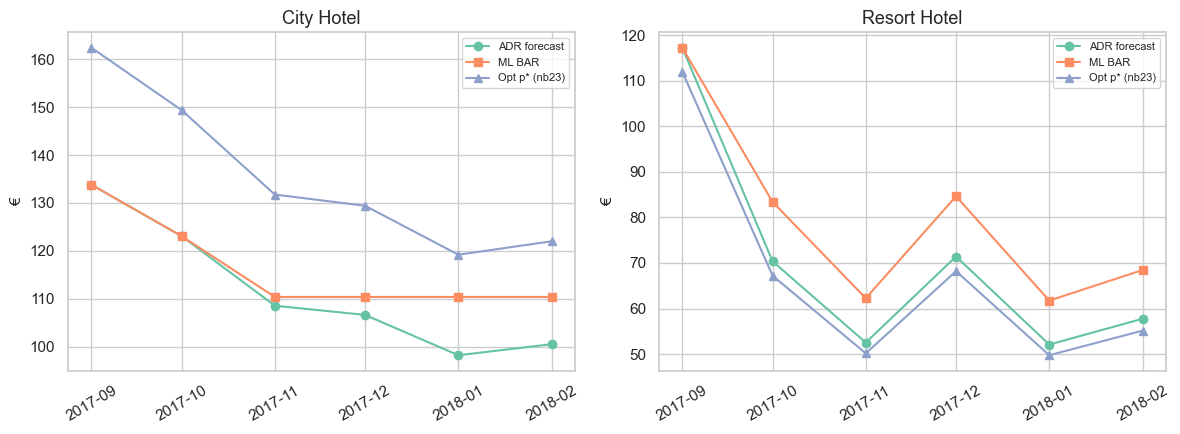

Saved: reports\figures\24_ml_pricing\compare\01_ml_vs_forecast_vs_opt.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/24_ml_pricing/compare/01_ml_vs_forecast_vs_opt.png')

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = inf[inf["hotel"] == hotel]
    ax.plot(sub["ym"], sub["fc_adr"], marker="o", label="ADR forecast")
    ax.plot(sub["ym"], sub["ml_adr"], marker="s", label="ML BAR")
    if opt is not None:
        o = opt[opt["hotel"] == hotel]
        ax.plot(o["ym"], o["p_star"], marker="^", label="Opt p* (nb23)")
    ax.set_title(hotel)
    ax.set_ylabel("€")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
savefig("01_ml_vs_forecast_vs_opt.png", slug="compare")

## 4. Ensemble recommend (ML ⊕ Optimization ⊕ Forecast stance)

Quy tắc đơn giản cho RM:

1. Lấy **trung vị** $\{p_{\mathrm{fc}},\, p_{\mathrm{ML}},\, p^*\}$ làm BAR đề xuất  
2. Nếu 2/3 tín hiệu CUT hoặc STIMULATE → cho phép promo có **floor = 0.85 × median**  
3. Nếu 2/3 RAISE/PROTECT → harden, cap promo

In [10]:
ens = inf[["hotel", "ym", "fc_adr", "ml_adr", "ml_stance", "pressure_adr", "pressure_revpar", "pressure_demand"]].copy()
if opt is not None:
    ens = ens.merge(opt[["hotel", "ym", "p_star", "action", "delta_price_pct"]], on=["hotel", "ym"], how="left")
else:
    ens["p_star"] = ens["fc_adr"]
    ens["action"] = "HOLD - keep forecast BAR"
    ens["delta_price_pct"] = 0.0

ens["bar_recommend"] = ens[["fc_adr", "ml_adr", "p_star"]].median(axis=1)
ens["bar_floor"] = 0.85 * ens["bar_recommend"]
ens["bar_ceil"] = 1.15 * ens["bar_recommend"]

def final_action(row) -> str:
    votes = []
    if row["ml_adr"] > row["fc_adr"] * 1.03:
        votes.append("RAISE")
    elif row["ml_adr"] < row["fc_adr"] * 0.97:
        votes.append("CUT")
    else:
        votes.append("HOLD")
    if str(row["action"]).startswith("RAISE"):
        votes.append("RAISE")
    elif str(row["action"]).startswith("CUT"):
        votes.append("CUT")
    else:
        votes.append("HOLD")
    # forecast pressure on ADR/RevPAR
    press = 0.5 * row["pressure_adr"] + 0.5 * row["pressure_revpar"]
    if press >= 1.1:
        votes.append("RAISE")
    elif press <= 0.9:
        votes.append("CUT")
    else:
        votes.append("HOLD")
    # majority
    for lab in ("RAISE", "CUT", "HOLD"):
        if votes.count(lab) >= 2:
            return lab
    return "HOLD"

ens["final_action"] = ens.apply(final_action, axis=1)
display(ens.round(2))
ens.to_csv(FIG_DIR / "ensemble_rate_recommend.csv", index=False)
ens.to_csv(FIG_DIR / "compare" / "city_vs_resort_ensemble.csv", index=False)
print("Saved ensemble_rate_recommend.csv")

,hotel,ym,fc_adr,ml_adr,ml_stance,pressure_adr,pressure_revpar,pressure_demand,p_star,action,delta_price_pct,bar_recommend,bar_floor,bar_ceil,final_action
0,City Hotel,2017-09-01,133.81,133.81,PROTECT,1.20,1.21,1.15,162.41,RAISE - harden BAR,21.38,133.81,113.74,153.88,RAISE
1,City Hotel,2017-10-01,123.07,123.07,PROTECT,1.09,1.07,1.14,149.38,RAISE - harden BAR,21.37,123.07,104.61,141.53,HOLD
2,City Hotel,2017-11-01,108.55,110.38,PROTECT,0.92,0.92,0.92,131.75,RAISE - harden BAR,21.38,110.38,93.82,126.93,HOLD
3,City Hotel,2017-12-01,106.62,110.38,PROTECT,0.94,0.85,0.79,129.41,RAISE - harden BAR,21.38,110.38,93.82,126.93,RAISE
4,City Hotel,2018-01-01,98.20,110.38,PROTECT,0.86,0.83,0.75,119.19,RAISE - harden BAR,21.38,110.38,93.82,126.93,RAISE
5,City Hotel,2018-02-01,100.51,110.38,PROTECT,0.90,0.89,0.95,121.99,RAISE - harden BAR,21.38,110.38,93.82,126.93,RAISE
6,Resort Hotel,2017-09-01,117.22,117.22,PROTECT,1.24,1.21,0.97,111.95,CUT - promo / stimulate,-4.50,117.22,99.64,134.81,HOLD
7,Resort Hotel,2017-10-01,70.37,83.39,PROTECT,0.77,0.80,1.12,67.20,CUT - promo / stimulate,-4.50,70.37,59.81,80.92,CUT
8,Resort Hotel,2017-11-01,52.53,62.25,PROTECT,0.59,0.66,0.91,50.17,CUT - promo / stimulate,-4.50,52.53,44.65,60.41,CUT
9,Resort Hotel,2017-12-01,71.41,84.63,PROTECT,0.78,0.83,0.90,68.20,CUT - promo / stimulate,-4.50,71.41,60.70,82.12,CUT


Saved ensemble_rate_recommend.csv


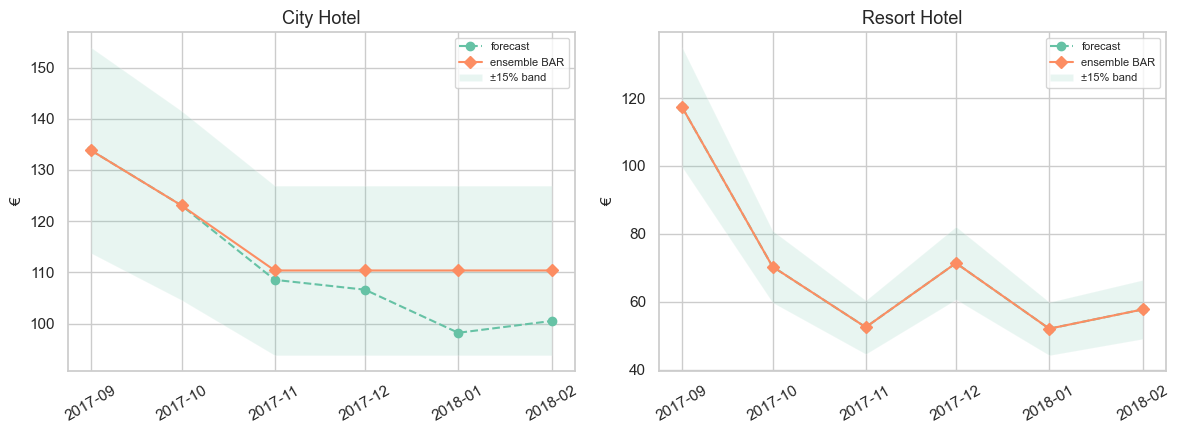

Saved: reports\figures\24_ml_pricing\compare\02_ensemble_bar_band.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/24_ml_pricing/compare/02_ensemble_bar_band.png')

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = ens[ens["hotel"] == hotel]
    ax.plot(sub["ym"], sub["fc_adr"], ls="--", marker="o", label="forecast")
    ax.plot(sub["ym"], sub["bar_recommend"], marker="D", label="ensemble BAR")
    ax.fill_between(sub["ym"], sub["bar_floor"], sub["bar_ceil"], alpha=0.15, label="±15% band")
    ax.set_title(hotel)
    ax.set_ylabel("€")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
savefig("02_ensemble_bar_band.png", slug="compare")

## 5. Hạn chế & next steps

1. Mẫu tháng ngắn → HGB sâu sẽ overfit; giữ `max_depth=3`.  
2. Multi-step horizon dùng lag state “đóng băng” — có thể recursive update nếu cần.  
3. Không có competitor rate / event calendar.  
4. Ensemble là heuristic vận hành, không phải RL.  
5. Re-fit khi có thêm tháng actual; so pickup vs `bar_recommend`.